# Sales & Demand Forecasting for Businesses

## Importing the required Libraries

In [56]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from prophet import Prophet

import warnings
warnings.filterwarnings("ignore")

## Importing the datasets (Store-sales-time-forecasting)

In [57]:

train = pd.read_csv("train.csv")

stores = pd.read_csv("stores.csv")

transactions = pd.read_csv("transactions.csv")

holidays = pd.read_csv("holidays_events.csv")

oil = pd.read_csv("oil.csv")

## printing the dimensions(number of rows,features) of datasets

In [58]:
print("Train:", train.shape)
print("Stores:", stores.shape)
print("Transactions:", transactions.shape)
print("Holidays:", holidays.shape)
print("Oil:", oil.shape)

Train: (3000888, 6)
Stores: (54, 5)
Transactions: (83488, 3)
Holidays: (350, 6)
Oil: (1218, 2)


## displaying first 5 rows of dataset

In [59]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


## displaying last 5 rows of datasets

In [60]:
train.tail()

,id,date,store_nbr,family,sales,onpromotion
3000883,3000883,2017-08-15,9,POULTRY,438.133,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8
3000887,3000887,2017-08-15,9,SEAFOOD,16.000,0


## displaying the summary of dataset i.e., features and its datatypes

In [229]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


## to check the missing values of each feature

In [230]:
train.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

#displaying the statistical information about the dataset

In [231]:
train.describe()

,id,date,store_nbr,sales,onpromotion
count,3.000888e+06,3000888,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2015-04-24 08:27:04.703088384,2.750000e+01,3.577757e+02,2.602770e+00
min,0.000000e+00,2013-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,2014-02-26 18:00:00,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2015-04-24 12:00:00,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,2016-06-19 06:00:00,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,2017-08-15 00:00:00,5.400000e+01,1.247170e+05,7.410000e+02
std,8.662819e+05,NaN,1.558579e+01,1.101998e+03,1.221888e+01


## converting date column into datetime format for time-series analysis

In [232]:
train['date'] = pd.to_datetime(train['date'])
transactions['date']=pd.to_datetime(transactions['date'])
oil['date'] = pd.to_datetime(oil['date'])
holidays['date'] = pd.to_datetime(holidays['date'])

In [233]:
oil['dcoilwtico'] = oil['dcoilwtico'].ffill().bfill()
transactions['transactions'] = transactions['transactions'].fillna(0)

In [234]:
# Merge stores data
train_data = train.merge(stores, on='store_nbr', how='left')

# Merge transactions
train_data = train_data.merge(
    transactions,
    on=['date', 'store_nbr'],
    how='left'
)

# Merge oil prices
train_data = train_data.merge(
    oil[['date', 'dcoilwtico']],
    on='date',
    how='left'
)

# Fill missing oil values
train_data['dcoilwtico'] = train_data['dcoilwtico'].ffill().bfill()

# Fill missing transactions
train_data['transactions'] = train_data['transactions'].fillna(0)

print(train_data.shape)
train_data.head()

(3000888, 12)


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,transactions,dcoilwtico
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,0.0,93.14
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,0.0,93.14
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,0.0,93.14
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,0.0,93.14
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,0.0,93.14


In [235]:
national_holidays = holidays[
    (holidays['locale'] == 'National') &
    (holidays['transferred'] == False)
]['date'].unique()

train_data['is_holiday'] = train_data['date'].isin(national_holidays).astype(int)

In [236]:
daily_sales = train_data.groupby('date').agg({
    'sales':        'sum',
    'transactions': 'sum',
    'dcoilwtico':   'mean',
    'is_holiday':   'max'
}).reset_index()

daily_sales.head()

,date,sales,transactions,dcoilwtico,is_holiday
0,2013-01-01,2511.618999,25410.0,93.14,1
1,2013-01-02,496092.417944,3076095.0,93.14,0
2,2013-01-03,361461.231124,2590632.0,92.97,0
3,2013-01-04,354459.677093,2590302.0,93.12,0
4,2013-01-05,477350.121229,3087909.0,93.12,1


## Feature Engineering

In [237]:
daily_sales['Year']      = daily_sales['date'].dt.year
daily_sales['Month']     = daily_sales['date'].dt.month
daily_sales['Day']       = daily_sales['date'].dt.day
daily_sales['DayOfWeek'] = daily_sales['date'].dt.dayofweek

# Lag features
daily_sales['Lag_1']  = daily_sales['sales'].shift(1)
daily_sales['Lag_7']  = daily_sales['sales'].shift(7)
daily_sales['Lag_30'] = daily_sales['sales'].shift(30)

# Rolling averages
daily_sales['Rolling_7']  = daily_sales['sales'].rolling(7).mean()
daily_sales['Rolling_30'] = daily_sales['sales'].rolling(30).mean()

daily_sales.dropna(inplace=True)

print(daily_sales.shape)
daily_sales.head()

(1654, 14)


,date,sales,transactions,dcoilwtico,is_holiday,Year,Month,Day,DayOfWeek,Lag_1,Lag_7,Lag_30,Rolling_7,Rolling_30
30,2013-01-31,271254.217996,2318844.0,97.65,0,2013,1,31,3,281061.127052,247245.690995,2511.618999,319499.837745,344170.437264
31,2013-02-01,369402.055266,2583966.0,97.46,0,2013,2,1,4,271254.217996,290022.771930,496092.417944,330839.735365,339947.425174
32,2013-02-02,518887.462705,3212451.0,97.46,0,2013,2,2,5,369402.055266,413799.767975,361461.231124,345852.263183,345194.966227
33,2013-02-03,486336.820180,2871858.0,97.46,0,2013,2,3,6,518887.462705,430411.991233,354459.677093,353841.524461,349590.870997
34,2013-02-04,344308.715017,2485890.0,96.21,0,2013,2,4,0,486336.820180,285460.169953,477350.121229,362248.459470,345156.157456


## Remove Missing Rows

In [238]:
daily_sales.dropna(inplace=True)

In [239]:
X = daily_sales.drop(
    ['date','sales'],
    axis=1
)

y = daily_sales['sales']

In [240]:
X.columns

Index(['transactions', 'dcoilwtico', 'is_holiday', 'Year', 'Month', 'Day',
       'DayOfWeek', 'Lag_1', 'Lag_7', 'Lag_30', 'Rolling_7', 'Rolling_30'],
      dtype='object')

## Splitting data into training and testing sets 

In [176]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,shuffle=False)
print(X_train.shape)
print(X_test.shape)

(1323, 12)
(331, 12)


In [241]:
results=[]

## Linear Regression

In [242]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

## Evaluating the performance of linear regression model

In [243]:
lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = mean_squared_error( y_test, lr_pred ) ** 0.5

lr_r2 = r2_score( y_test, lr_pred )

print("MAE :", lr_mae)
print("RMSE:", lr_rmse) 
print("R² :", lr_r2)

MAE : 76524.85244732453
RMSE: 107569.81547972278
R² : 0.6630904774808117


In [244]:
results.append([
    'Linear Regression',
    lr_mae,
    lr_rmse,
    lr_r2
])

## Random Forest

In [245]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [246]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = mean_squared_error(
    y_test,
    rf_pred
) ** 0.5

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

MAE : 55499.90585781879
RMSE: 81510.14592294238
R²  : 0.8065557700428214


In [247]:
results.append([
    'Random Forest',
    rf_mae,
    rf_rmse,
    rf_r2
])

## XGBoost

In [248]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [249]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = mean_squared_error(
    y_test,
    xgb_pred
) ** 0.5

xgb_r2 = r2_score(
    y_test,
    xgb_pred
)

print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²  :", xgb_r2)

MAE : 56490.34908269124
RMSE: 87271.71041275567
R²  : 0.7782419397042609


In [250]:
results.append([
    'XGBoost',
    xgb_mae,
    xgb_rmse,
    xgb_r2
])

In [251]:
results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'MAE',
        'RMSE',
        'R2'
    ]
)

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,76524.852447,107569.815480,0.663090
1,Random Forest,55499.905858,81510.145923,0.806556
2,XGBoost,56490.349083,87271.710413,0.778242


In [255]:
from statsmodels.tsa.arima.model import ARIMA

In [256]:
sales_series = daily_sales['sales']

train_size = int(len(sales_series) * 0.8)

train_ts = sales_series[:train_size]
test_ts = sales_series[train_size:]

In [257]:
arima_model = ARIMA(
    train_ts,
    order=(5,1,0)
)

arima_fit = arima_model.fit()

In [258]:
arima_pred = arima_fit.forecast(
    steps=len(test_ts)
)

In [259]:
arima_mae = mean_absolute_error(
    test_ts,
    arima_pred
)

arima_rmse = mean_squared_error(
    test_ts,
    arima_pred
) ** 0.5

arima_r2 = r2_score(
    test_ts,
    arima_pred
)

print("MAE :", arima_mae)
print("RMSE:", arima_rmse)
print("R²  :", arima_r2)

MAE : 164071.20557967728
RMSE: 226789.91013188384
R²  : -0.49754505263488813


In [260]:
results.append([
    'ARIMA',
    arima_mae,
    arima_rmse,
    arima_r2
])

## Exponential Smoothing

In [261]:
exp_model = ExponentialSmoothing(
    train_ts,
    trend='add',
    seasonal=None
)

exp_fit = exp_model.fit()

In [262]:
exp_pred = exp_fit.forecast(
    len(test_ts)
)

In [263]:
exp_mae = mean_absolute_error(
    test_ts,
    exp_pred
)

exp_rmse = mean_squared_error(
    test_ts,
    exp_pred
) ** 0.5

exp_r2 = r2_score(
    test_ts,
    exp_pred
)

print("MAE :", exp_mae)
print("RMSE:", exp_rmse)
print("R²  :", exp_r2)

MAE : 142315.33949913646
RMSE: 194905.8861002603
R²  : -0.10606932649284606


In [264]:
results.append([
    'Exponential Smoothing',
    exp_mae,
    exp_rmse,
    exp_r2
])

## Prophet

In [265]:
from prophet import Prophet

In [266]:
prophet_df = daily_sales[['date','sales']]

prophet_df.columns = [
    'ds',
    'y'
]

In [267]:
train_prophet = prophet_df.iloc[:train_size]

test_prophet = prophet_df.iloc[train_size:]

In [268]:
prophet_model = Prophet()

prophet_model.fit(
    train_prophet
)

21:13:26 - cmdstanpy - INFO - Chain [1] start processing
21:13:26 - cmdstanpy - INFO - Chain [1] done processing


In [269]:
future = prophet_model.make_future_dataframe(
    periods=len(test_prophet)
)

forecast = prophet_model.predict(
    future
)

In [270]:
prophet_pred = forecast['yhat'].iloc[
    -len(test_prophet):
].values

In [271]:
prophet_mae = mean_absolute_error(
    test_prophet['y'],
    prophet_pred
)

prophet_rmse = mean_squared_error(
    test_prophet['y'],
    prophet_pred
) ** 0.5

prophet_r2 = r2_score(
    test_prophet['y'],
    prophet_pred
)

print("MAE :", prophet_mae)
print("RMSE:", prophet_rmse)
print("R²  :", prophet_r2)

MAE : 136469.34440976204
RMSE: 178551.53159923124
R²  : 0.07176145465440398


In [272]:
results.append([
    'Prophet',
    prophet_mae,
    prophet_rmse,
    prophet_r2
])

## Comparing model performance using MAE, RMSE, and R² metrics

In [273]:
results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'MAE',
        'RMSE',
        'R2'
    ]
)

results_df.sort_values(
    by='RMSE'
)

,Model,MAE,RMSE,R2
1,Random Forest,55499.905858,81510.145923,0.806556
2,XGBoost,56490.349083,87271.710413,0.778242
0,Linear Regression,76524.852447,107569.815480,0.663090
5,Prophet,136469.344410,178551.531599,0.071761
4,Exponential Smoothing,142315.339499,194905.886100,-0.106069
3,ARIMA,164071.205580,226789.910132,-0.497545


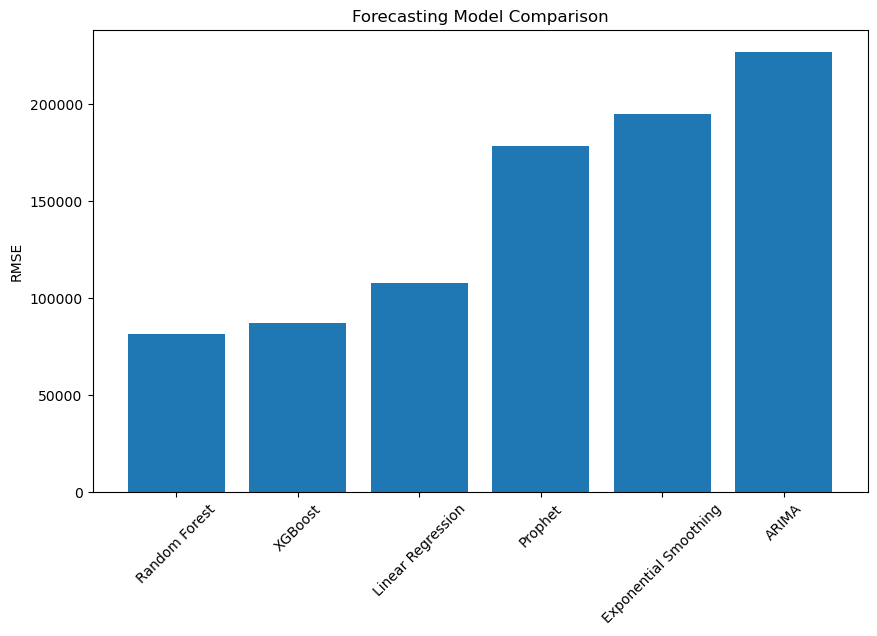

In [281]:
results_df = results_df.sort_values(by='RMSE')

plt.figure(figsize=(10,6))

plt.bar(
    results_df['Model'],
    results_df['RMSE']
)

plt.xticks(rotation=45)

plt.title(
    "Forecasting Model Comparison"
)

plt.ylabel("RMSE")

plt.show()prob

## Visual comparison of forecasting models based on RMSE

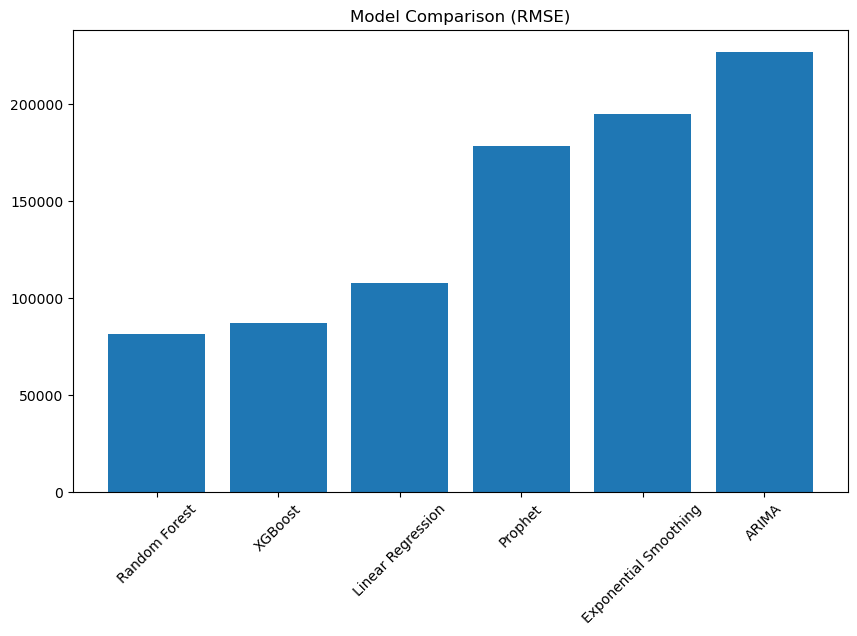

In [283]:
plt.figure(figsize=(10,6))

plt.bar(
    results_df['Model'],
    results_df['RMSE']
)

plt.xticks(rotation=45)

plt.title(
    'Model Comparison (RMSE)'
)
plt.show()

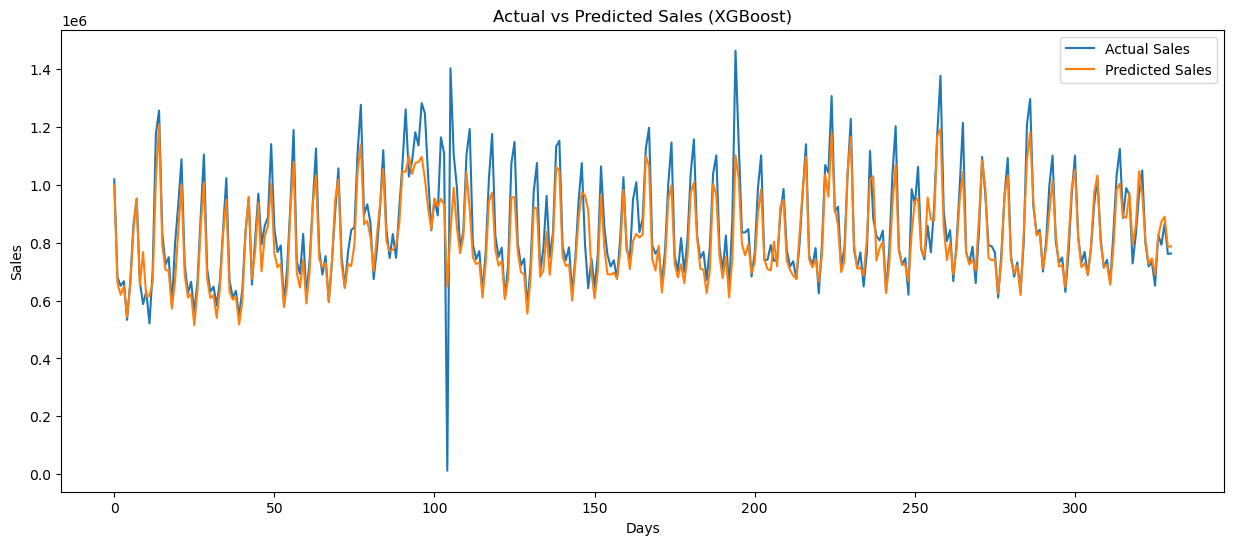

In [282]:

plt.figure(figsize=(15,6))

plt.plot(
    y_test.values,
    label='Actual Sales'
)

plt.plot(
    xgb_pred,
    label='Predicted Sales'
)

plt.title('Actual vs Predicted Sales (XGBoost)')
plt.xlabel('Days')
plt.ylabel('Sales')

plt.legend()

plt.show()

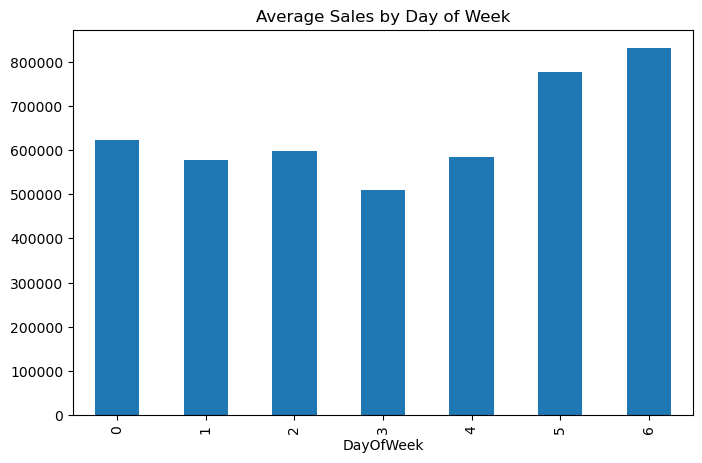

In [285]:
dow = daily_sales.groupby(
    'DayOfWeek'
)['sales'].mean()

plt.figure(figsize=(8,5))

dow.plot(kind='bar')

plt.title(
    'Average Sales by Day of Week'
)

plt.show()

Model selection:

XGBoost is selected because it achieves the best RMSE and R². RMSE penalises large errors more heavily, making it the more reliable metric for business planning. The MAE difference vs Random Forest is marginal, and XGBoost’s higher R² confirms the stronger overall fit.

## Feature Importance

In [274]:
importance = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)

## Identifying the most influential features used by the XGBoost model

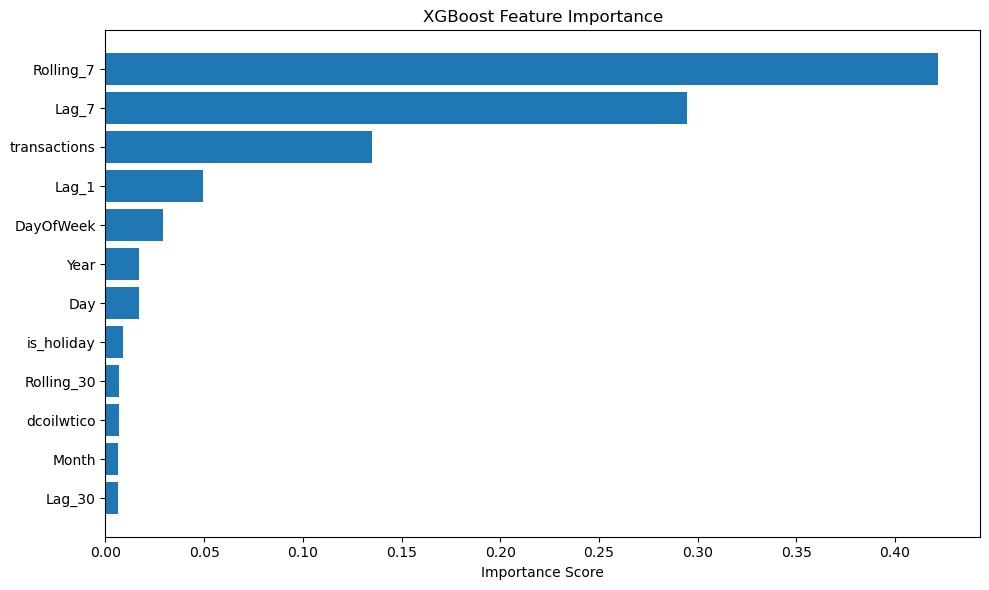

In [275]:
plt.figure(figsize=(10, 6))
plt.barh(importance['Feature'], importance['Importance'])
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Generating future dates for 30-day sales forecasting

In [276]:
future_dates = pd.date_range(
    start   = daily_sales['date'].max() + pd.Timedelta(days=1),
    periods = 30
)

future_df = pd.DataFrame({'date': future_dates})


future_df['Year']      = future_df['date'].dt.year
future_df['Month']     = future_df['date'].dt.month
future_df['Day']       = future_df['date'].dt.day
future_df['DayOfWeek'] = future_df['date'].dt.dayofweek


last_sales = daily_sales['sales'].iloc[-1]
lag_7      = daily_sales['sales'].iloc[-7]
lag_30     = daily_sales['sales'].iloc[-30]
rolling_7  = daily_sales['sales'].iloc[-7:].mean()
rolling_30 = daily_sales['sales'].iloc[-30:].mean()

future_df['Lag_1']    = last_sales
future_df['Lag_7']    = lag_7
future_df['Lag_30']   = lag_30
future_df['Rolling_7']  = rolling_7
future_df['Rolling_30'] = rolling_30


future_df['transactions'] = daily_sales['transactions'].mean()
future_df['dcoilwtico']   = daily_sales['dcoilwtico'].mean()
future_df['is_holiday']   = 0

future_X = future_df[X.columns]

# Predict
future_df['Forecasted_Sales'] = xgb.predict(future_X)

future_df[['date', 'Forecasted_Sales']].head(10)

,date,Forecasted_Sales
0,2017-08-16,741389.6250
1,2017-08-17,712414.0000
2,2017-08-18,718820.3750
3,2017-08-19,761873.6875
4,2017-08-20,815509.2500
5,2017-08-21,723614.1250
6,2017-08-22,719920.8125
7,2017-08-23,735445.9375
8,2017-08-24,710786.6250
9,2017-08-25,717069.1250


## Visualizing forecasted sales for the next 30 days

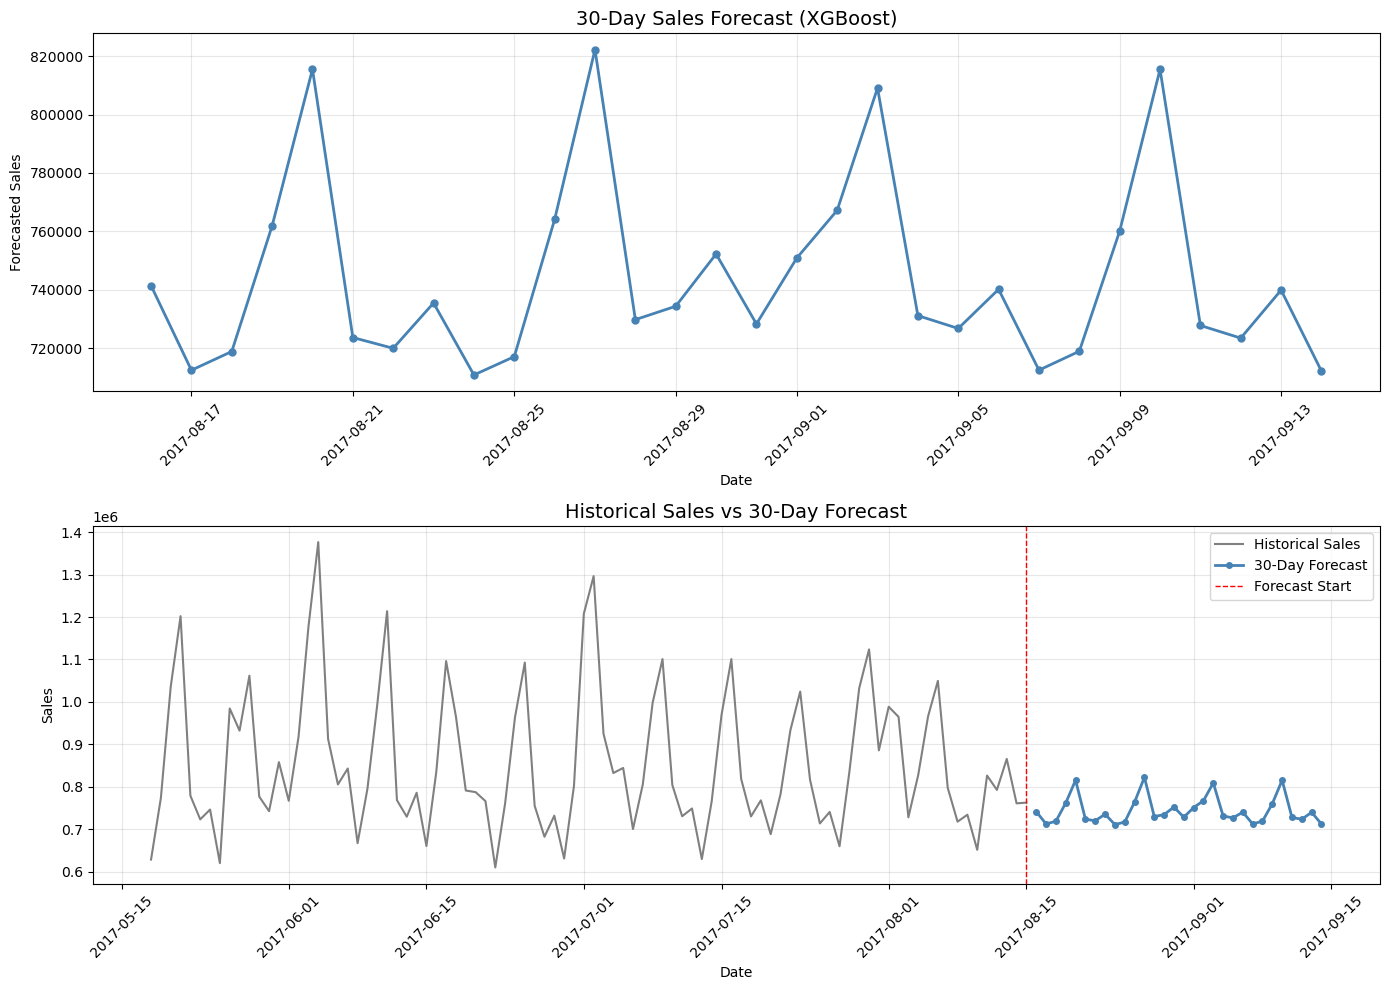

Chart saved.


In [280]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))


axes[0].plot(
    future_df['date'],
    future_df['Forecasted_Sales'],
    marker='o', color='steelblue', linewidth=2, markersize=5
)
axes[0].set_title('30-Day Sales Forecast (XGBoost)', fontsize=14)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Forecasted Sales')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)


last_90 = daily_sales.tail(90)
axes[1].plot(
    last_90['date'],
    last_90['sales'],
    label='Historical Sales', color='grey', linewidth=1.5
)
axes[1].plot(
    future_df['date'],
    future_df['Forecasted_Sales'],
    label='30-Day Forecast', color='steelblue', linewidth=2, marker='o', markersize=4
)
axes[1].axvline(
    x=daily_sales['date'].max(),
    color='red', linestyle='--', linewidth=1, label='Forecast Start'
)
axes[1].set_title('Historical Sales vs 30-Day Forecast', fontsize=14)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Sales')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Chart saved.")

## Forecast Interpretation & Business Recommendations

The XGBoost model forecasts **total daily sales across all stores for the next 30 days**:

- **Weekend sales spike consistently** — Saturdays/Sundays are notably higher than weekdays.
- **Early-month demand rises**, suggesting a seasonal uptick.
- **The 7-day rolling average** was the most influential feature — last week's sales predict next week's best.

---

### How a Business Can Use This Forecast

| Action | Recommendation |
|--------|----------------|
| **Inventory** | Stock up 5–7 days before weekend spikes; order extra for the early-month peak. |
| **Staffing** | Schedule more staff Fri–Sat to handle higher weekend volume. |
| **Promotions** | Run mid-week deals (Tue–Wed) to lift low-demand days and smooth the curve. |
| **Cash Flow** | Plan supplier payments around the revenue peak days. |
| **Logistics** | Schedule bulk deliveries Mon–Tue to replenish before weekend surges. |

## Conclusion

-This project developed a sales forecasting system using historical retail sales data.
-Six forecasting models were trained and evaluated: Linear Regression, Random Forest, XGBoost, ARIMA, Exponential Smoothing, and Prophet.
-Among all models, XGBoost achieved the best performance based on RMSE and R² metrics.
-The generated 30-day sales forecast demonstrates how machine learning can support inventory planning, demand forecasting, and business decision-making.



In [286]:
# Dashboard Summary
print(f"Best Model : XGBoost")
print(f"RMSE       : {xgb_rmse:.2f}")
print(f"R² Score   : {xgb_r2:.4f}")
print(f"Forecast Days : 30")

Best Model : XGBoost
RMSE       : 87271.71
R² Score   : 0.7782
Forecast Days : 30


In [287]:
daily_sales.to_csv("daily_sales.csv", index=False)

future_df.to_csv("future_forecast.csv", index=False)

print("Files saved successfully!")

Files saved successfully!


In [288]:
print(daily_sales.columns)
print(future_df.columns)

Index(['date', 'sales', 'transactions', 'dcoilwtico', 'is_holiday', 'Year',
       'Month', 'Day', 'DayOfWeek', 'Lag_1', 'Lag_7', 'Lag_30', 'Rolling_7',
       'Rolling_30'],
      dtype='object')
Index(['date', 'Year', 'Month', 'Day', 'DayOfWeek', 'Lag_1', 'Lag_7', 'Lag_30',
       'Rolling_7', 'Rolling_30', 'transactions', 'dcoilwtico', 'is_holiday',
       'Forecasted_Sales'],
      dtype='object')
